In [306]:
import torch
import torch.nn as nn
import numpy as np
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt  
# from tensorflow.keras.preprocessing import image  
device = torch.device('cpu')


In [307]:
img_path = 'test_Real.jpg'
#img_path = 'test_Deepfake.jpg'
img = Image.open(img_path).resize((224, 224))
img = np.array(img)
img = np.array(img).astype('float32')

In [308]:
from PIL import Image
import matplotlib.pyplot as plt

def show_data(img, title=""):
    plt.figure(figsize=(5, 5))
    if isinstance(img, np.ndarray):
        plt.imshow(img.astype("uint8"))
    elif isinstance(img, Image.Image):
        plt.imshow(img)
    else:
        plt.imshow(np.array(img).astype("uint8"))
    plt.axis("off")
    plt.title(title)


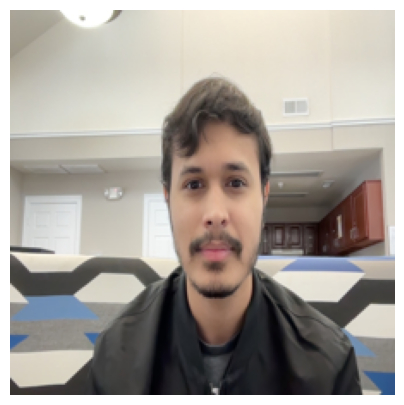

In [309]:
show_data(img)

In [310]:
def preprocess_pil(img: Image.Image) -> torch.Tensor:
    # Resize to 224x224
    img = img.resize((224, 224))

    # Convert to numpy float32, scale to [0, 1]
    img_np = np.asarray(img, dtype=np.float32) / 255.0

    # Normalize using ImageNet mean/std
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)
    img_np = (img_np - mean) / std

    img_np = img_np.transpose(2, 0, 1)

    return torch.tensor(img_np, dtype=torch.float32)


In [311]:
image = Image.open(img_path).convert('RGB')

img_np = np.asarray(image, dtype=np.uint8)

input_tensor = preprocess_pil(image).unsqueeze(0).to(device)
print("Input tensor shape:", input_tensor.shape)
print("Device:", input_tensor.device)


Input tensor shape: torch.Size([1, 3, 224, 224])
Device: cpu


In [312]:
from VisionKAN import create_model, train_one_epoch, evaluate

KAN = create_model(
    model_name='deit_tiny_patch16_224_KAN',
    pretrained=False,
    hdim_kan=192,
    num_classes=1,
    drop_rate=0.0,
    drop_path_rate=0.05,
    img_size=224,
    batch_size=32
)

# VisionLSTM model
vision_lstm = torch.hub.load("nx-ai/vision-lstm", "VisionLSTM", 
    dim=192,  
    depth=24,  
    patch_size=16,
    input_shape=(3, 224, 224),  
    output_shape=(1,),  
    drop_path_rate=0.05,  
    stride=None 
)

{'hdim_kan': 192, 'num_classes': 1, 'drop_rate': 0.0, 'drop_path_rate': 0.05, 'img_size': 224, 'batch_size': 32}


Using cache found in /Users/isitthakkar/.cache/torch/hub/nx-ai_vision-lstm_main


In [313]:
# Custom Model combining ViT and VisionLSTM
class CombinedModel(nn.Module):
    def __init__(self, KAN, vision_lstm):
        super(CombinedModel, self).__init__()
        self.KAN = KAN
        self.vision_lstm = vision_lstm
        self.fc1 = nn.Linear(2, 512)
        self.fc2 = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        KAN_output = self.KAN(x)
        lstm_output = self.vision_lstm(x)
        combined = torch.cat((KAN_output, lstm_output), dim=1)
        x = self.fc1(combined)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = CombinedModel(KAN, vision_lstm).to(device)

In [314]:
import os

weights_path = "as_model_best.pt"

if os.path.exists(weights_path):
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Loaded trained weights from {weights_path}")
else:
    print(f"WARNING: {weights_path} not found. Using randomly initialized model; predictions will not be meaningful.")

model.eval()


Loaded trained weights from as_model_best.pt


CombinedModel(
  (KAN): VisionKAN(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): kanBlock(
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=False)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=192, out_features=768, bias=True)
          (act): GELU(approximate='none')
      

In [315]:
# Predict
with torch.no_grad():
    output = model(input_tensor)
    prob = output.item()

# Threshold at 0.5
if prob < 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: REAL
